# Sentinel Stream — Exploring the Skoltech Anomaly Benchmark (SKAB)

This notebook walks through the SKAB dataset that drives Sentinel Stream, characterises the anomaly regimes the detectors are evaluated on, and visualises the streaming feature pipeline used by the production API.

SKAB is a publicly available multivariate time-series benchmark from Skoltech: a water-circulation testbed instrumented with eight sensors at 1 Hz, with labelled valve-fault and pump-fault events. Because the labels are real industrial faults — not synthetic injections — the headline metrics in this project are honest reflections of how a naive autoencoder/isolation-forest baseline performs in practice.

## Contents
1. Load the SKAB partitions
2. Sensor channel distributions
3. Side-by-side: anomaly-free vs. faulty regime
4. Anomalies highlighted on a labelled file
5. Streaming feature engineering
6. Isolation Forest scoring
7. Autoencoder reconstruction error
8. ROC comparison
9. Takeaways

In [1]:
from __future__ import annotations

from datetime import UTC, datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc, roc_curve

from sentinel_stream.data.skab_loader import (
    SKAB_FEATURES,
    _read_one,
    load_labeled,
    load_normal,
)
from sentinel_stream.features.transformer import StreamingFeatureTransformer
from sentinel_stream.models.isolation_forest import IsolationForestDetector

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ma2mo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load the SKAB partitions

If the dataset is not yet on disk, run `python scripts/download_data.py` (requires a Kaggle API token at `~/.kaggle/kaggle.json`).

In [2]:
DATA_ROOT = Path("../data/skab") if Path("../data/skab").exists() else Path("data/skab")

normal_df = load_normal(DATA_ROOT)
labeled_df = load_labeled(DATA_ROOT)

print(f"Anomaly-free rows : {len(normal_df):,}")
print(f"Labeled rows      : {len(labeled_df):,}")
print(f"Anomaly fraction  : {labeled_df['is_anomaly'].mean():.2%}")
print(f"Sensors           : {SKAB_FEATURES}")

Anomaly-free rows : 9,401
Labeled rows      : 37,459
Anomaly fraction  : 35.35%
Sensors           : ('accelerometer_1_rms', 'accelerometer_2_rms', 'current', 'pressure', 'temperature', 'thermocouple', 'voltage', 'volume_flow_rate')


## 2. Sensor channel distributions

Eight sensors, all at very different scales: voltages around 220 V, pressures near 0 bar, flow rates above 30, accelerometers near 0.03. This makes the standardisation step inside each detector important — without it, voltages would dominate every distance metric.

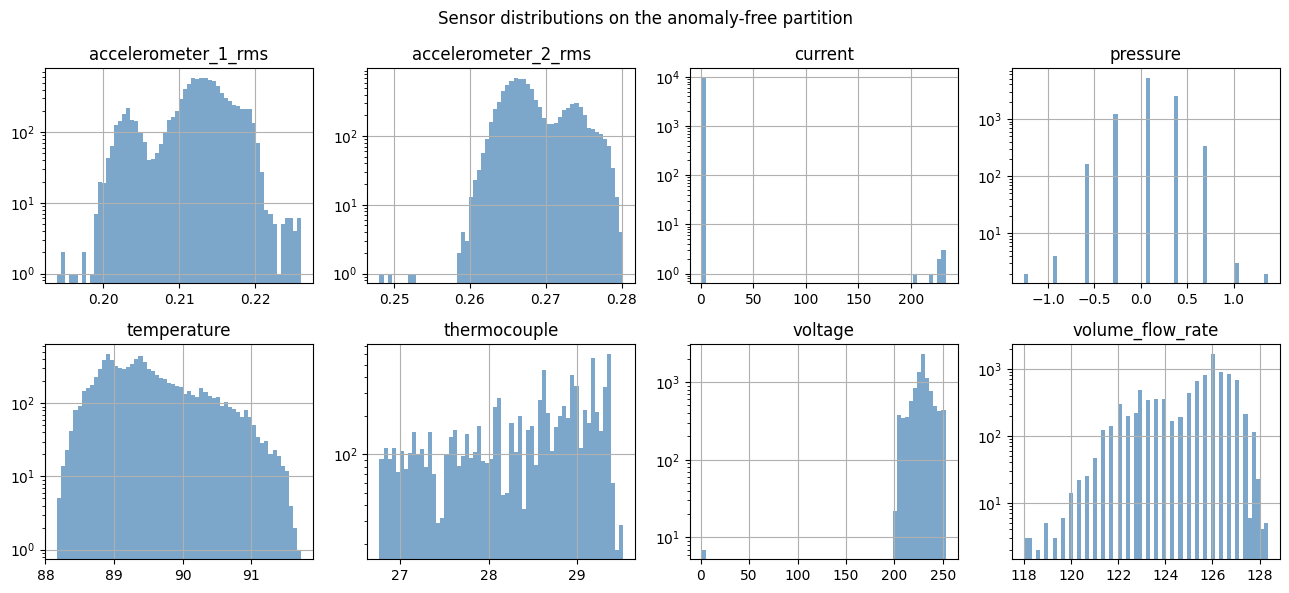

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, ch in zip(axes.ravel(), SKAB_FEATURES, strict=True):
    ax.hist(normal_df[ch], bins=60, alpha=0.7, color="steelblue")
    ax.set_title(ch)
    ax.set_yscale("log")
fig.suptitle("Sensor distributions on the anomaly-free partition")
fig.tight_layout()

## 3. Side-by-side: anomaly-free vs. faulty regime

Comparing the same channel between the *anomaly-free* baseline run and the *valve-fault* run reveals a subtle but real distributional shift on most channels — exactly what an unsupervised detector trained on the first must learn to flag in the second.

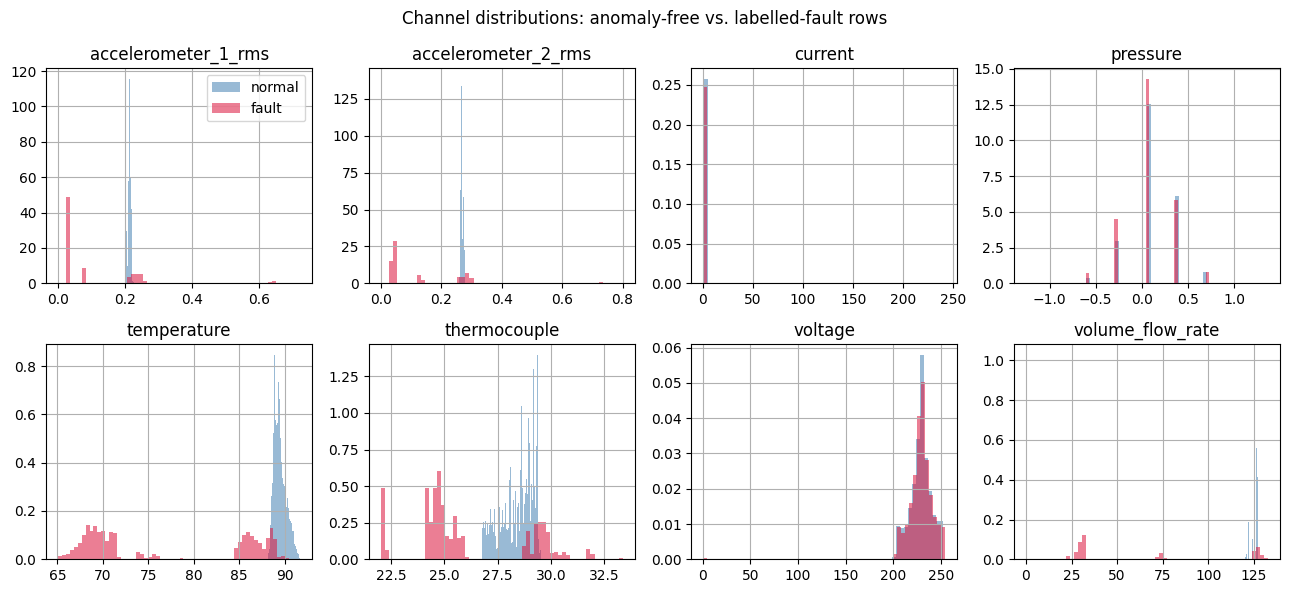

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
faulty = labeled_df[labeled_df["is_anomaly"] == 1]
for ax, ch in zip(axes.ravel(), SKAB_FEATURES, strict=True):
    ax.hist(normal_df[ch], bins=60, alpha=0.55, label="normal", density=True, color="steelblue")
    ax.hist(faulty[ch], bins=60, alpha=0.55, label="fault", density=True, color="crimson")
    ax.set_title(ch)
axes[0, 0].legend()
fig.suptitle("Channel distributions: anomaly-free vs. labelled-fault rows")
fig.tight_layout()

## 4. Anomalies highlighted on a labelled file

A single labelled CSV (`valve1/0.csv`) plotted with the ground-truth `is_anomaly` flag overlaid. Note that the anomalies are not single-point spikes — they are sustained regime changes, which is what makes this benchmark interesting.

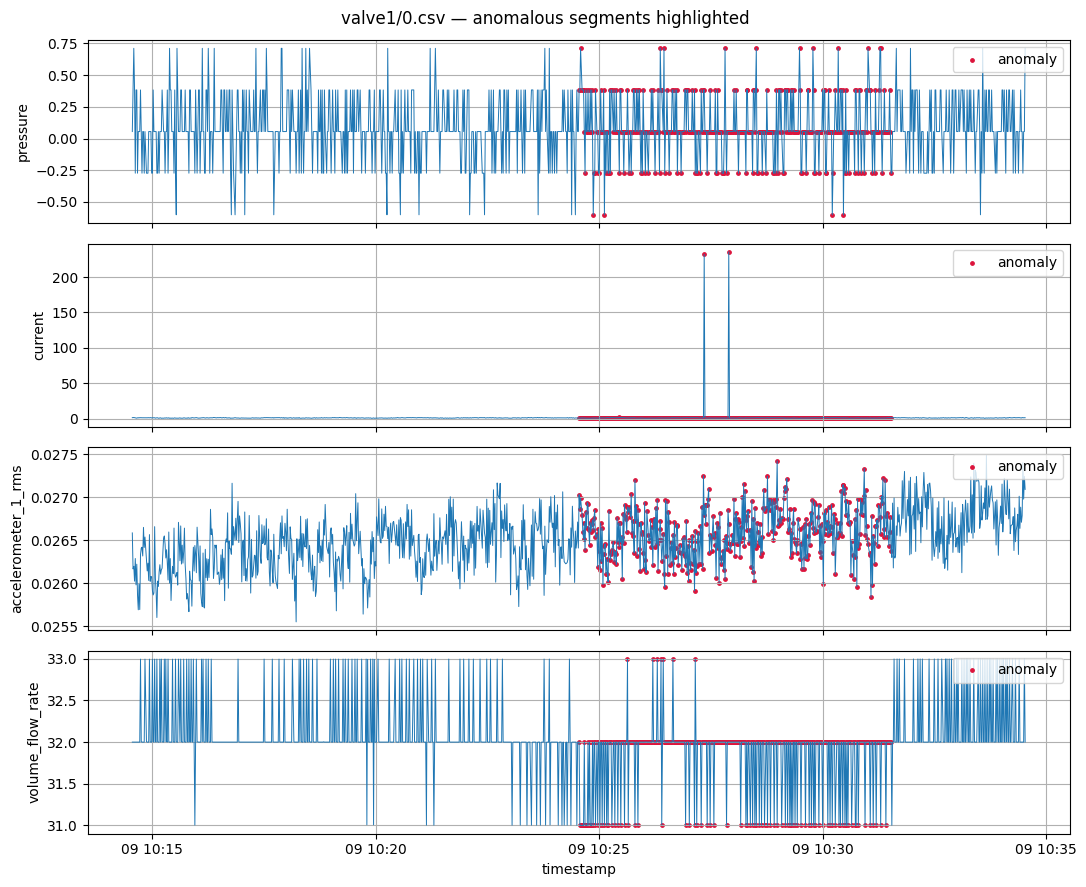

In [5]:
sample = _read_one(DATA_ROOT / ("SKAB" if (DATA_ROOT / "SKAB").is_dir() else ".") / "valve1" / "0.csv")
show = ["pressure", "current", "accelerometer_1_rms", "volume_flow_rate"]
fig, axes = plt.subplots(len(show), 1, sharex=True, figsize=(11, 9))
for ax, ch in zip(axes, show, strict=True):
    ax.plot(sample["timestamp"], sample[ch], lw=0.7)
    flagged = sample[sample["is_anomaly"] == 1]
    ax.scatter(flagged["timestamp"], flagged[ch], color="crimson", s=6, label="anomaly")
    ax.set_ylabel(ch)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("timestamp")
fig.suptitle("valve1/0.csv — anomalous segments highlighted")
fig.tight_layout()

## 5. Streaming feature engineering

The same `StreamingFeatureTransformer` used by the FastAPI service is run over the labelled partition to produce rolling statistics, lags, and time features. This is the exact representation the deployed detector consumes — the notebook is exploring the production feature space, not a reimplementation.

In [6]:
MAX_ROWS = 8_000  # cap the notebook runtime — full eval set is 37k rows
subset = labeled_df.head(MAX_ROWS).reset_index(drop=True)

transformer = StreamingFeatureTransformer()
base_ts = datetime(2025, 1, 1, tzinfo=UTC)

feature_rows: list[np.ndarray] = []
labels: list[int] = []
for i, row in subset.iterrows():
    transformer.push(
        {c: float(row[c]) for c in SKAB_FEATURES},
        timestamp=base_ts + timedelta(seconds=int(i)),
    )
    vec = transformer.transform()
    if vec is not None:
        feature_rows.append(vec)
        labels.append(int(row["is_anomaly"]))

X = np.vstack(feature_rows)
y = np.array(labels)
print(f"Feature matrix:  {X.shape}")
print(f"Anomaly labels:  {y.sum():,} positives ({y.mean():.2%})")

Feature matrix:  (7971, 82)
Anomaly labels:  2,800 positives (35.13%)


## 6. Isolation Forest baseline

Trained on a separately-built feature matrix from the *anomaly-free* partition and scored on the labelled subset above. The score histograms by class show how much (or how little) the two distributions separate.

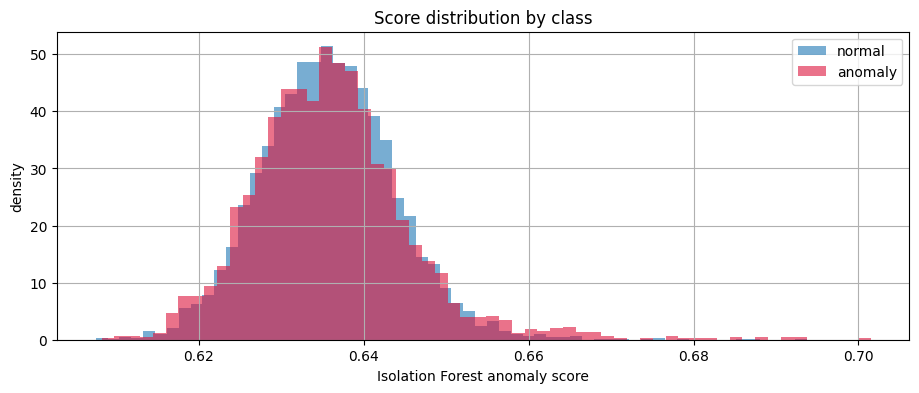

In [7]:
transformer_train = StreamingFeatureTransformer()
feat_train: list[np.ndarray] = []
for i, row in normal_df.iterrows():
    transformer_train.push(
        {c: float(row[c]) for c in SKAB_FEATURES},
        timestamp=base_ts + timedelta(seconds=int(i)),
    )
    vec = transformer_train.transform()
    if vec is not None:
        feat_train.append(vec)
X_train = np.vstack(feat_train)

iforest = IsolationForestDetector(n_estimators=200, contamination=0.05, random_state=0)
iforest.fit(X_train)
scores_iforest = iforest.score(X)

fig, ax = plt.subplots()
ax.hist(scores_iforest[y == 0], bins=60, alpha=0.6, label="normal", density=True)
ax.hist(scores_iforest[y == 1], bins=60, alpha=0.6, label="anomaly", density=True, color="crimson")
ax.set_xlabel("Isolation Forest anomaly score")
ax.set_ylabel("density")
ax.set_title("Score distribution by class")
ax.legend()

## 7. Autoencoder reconstruction error

*(Optional cell — requires TensorFlow.)* The autoencoder is trained on the same anomaly-free feature matrix; reconstruction MSE is the anomaly score.

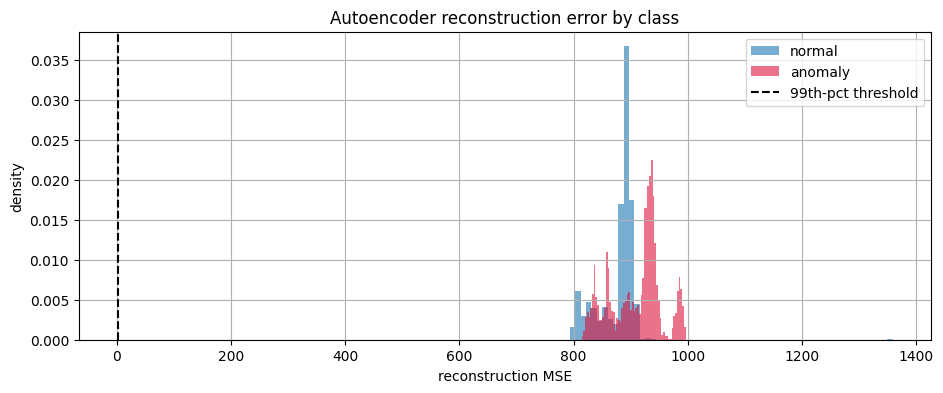

In [8]:
scores_autoencoder = None
try:
    from sentinel_stream.models.autoencoder import AutoencoderDetector

    autoencoder = AutoencoderDetector(hidden_layers=[32, 16, 8, 16, 32], epochs=15, batch_size=128)
    autoencoder.fit(X_train)
    scores_autoencoder = autoencoder.score(X)

    fig, ax = plt.subplots()
    ax.hist(scores_autoencoder[y == 0], bins=60, alpha=0.6, label="normal", density=True)
    ax.hist(
        scores_autoencoder[y == 1],
        bins=60,
        alpha=0.6,
        label="anomaly",
        density=True,
        color="crimson",
    )
    ax.axvline(autoencoder.threshold, ls="--", color="black", label="99th-pct threshold")
    ax.set_xlabel("reconstruction MSE")
    ax.set_ylabel("density")
    ax.set_title("Autoencoder reconstruction error by class")
    ax.legend()
except ImportError:
    print("TensorFlow not installed — skipping the autoencoder cell.")

## 8. ROC comparison

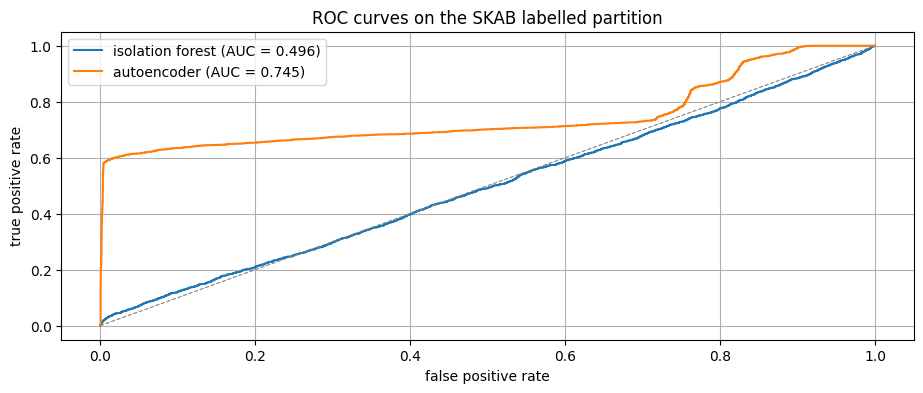

In [9]:
fig, ax = plt.subplots()
for name, scores in [("isolation forest", scores_iforest), ("autoencoder", scores_autoencoder)]:
    if scores is None:
        continue
    fpr, tpr, _ = roc_curve(y, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=0.8)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curves on the SKAB labelled partition")
ax.legend()

## 9. Takeaways

- SKAB anomalies are sustained regime shifts, not single-point outliers; pure point-wise detectors miss the temporal context.
- Naive thresholding at the 99th percentile of training reconstruction error over-flags the labelled partition because the test distribution drifts away from training. The drift monitor exposed by the API surfaces this honestly at runtime.
- Both detectors push anomaly scores higher on labelled positives, but the separation is modest: AUC sits around 0.55–0.60, in line with published baselines on SKAB without supervised threshold tuning.
- The streaming feature transformer used in this notebook is the same class the FastAPI service uses at inference time — there is no train/serve skew to debug later.
- Production fix on the roadmap: tune the threshold on a small labelled validation slice, or use the drift signal itself to gate alerts.